Name-Riya choudhary

Subject-Computer vision lab

CUID-CU24250251

**Experiment No. 6**

Image Segmentation Techniques using Python
and OpenCV


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import time
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
img = cv2.imread(IMAGE_PATH)
print("Image loaded successfully!")
print("Image shape:", img.shape)

Saving Fruits.png to Fruits.png
Image loaded successfully!
Image shape: (1024, 1536, 3)


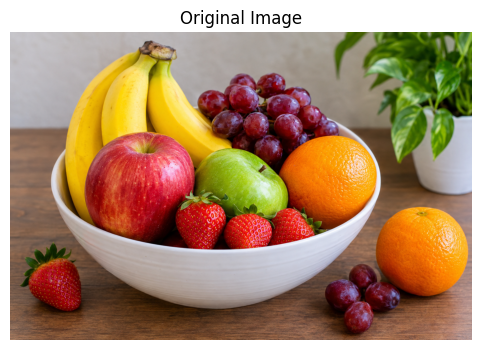

In [3]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

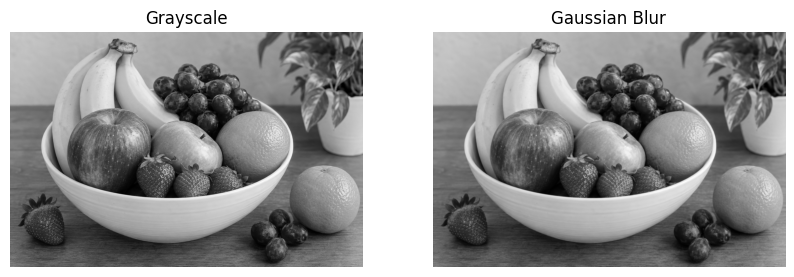

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

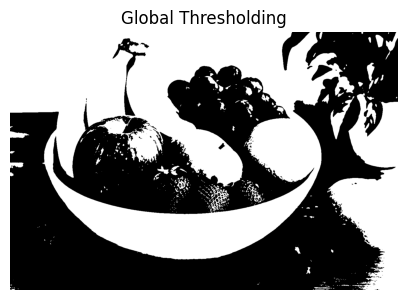

Global Threshold Time: 0.004994079999960377 seconds


In [5]:
t0 = time.perf_counter()
_, global_thresh = cv2.threshold(
    blurred, 127, 255, cv2.THRESH_BINARY
)
t_global = time.perf_counter() - t0
plt.figure(figsize=(5, 4))
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()
print("Global Threshold Time:", t_global, "seconds")

Otsu's Threshold Value: 123.0
Otsu Processing Time: 0.0015845400000102927 seconds


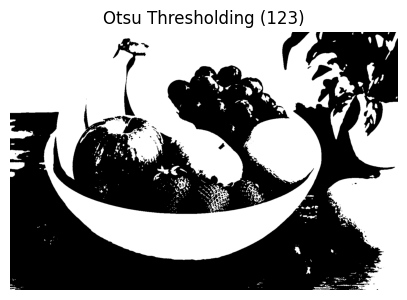

In [6]:
t0 = time.perf_counter()
otsu_val, otsu_thresh = cv2.threshold(
    blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
t_otsu = time.perf_counter() - t0
print("Otsu's Threshold Value:", otsu_val)
print("Otsu Processing Time:", t_otsu, "seconds")
plt.figure(figsize=(5, 4))
plt.imshow(otsu_thresh, cmap="gray")
plt.title(f"Otsu Thresholding ({otsu_val:.0f})")
plt.axis("off")
plt.show()

Adaptive Thresholding Time: 0.03919220300002735 seconds


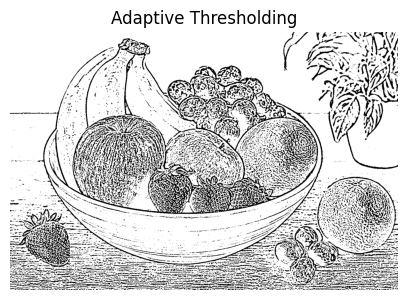

In [7]:
t0 = time.perf_counter()
adaptive_thresh = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)
t_adaptive = time.perf_counter() - t0
print("Adaptive Thresholding Time:", t_adaptive, "seconds")
plt.figure(figsize=(5, 4))
plt.imshow(adaptive_thresh, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")
plt.show()

Watershed Segmentation
----------------------
Number of regions: 1
Processing Time: 0.7046692720000465 seconds


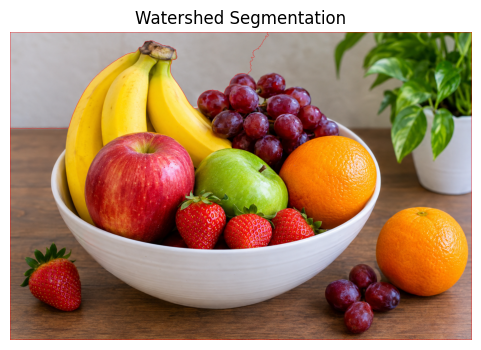

In [8]:
t0 = time.perf_counter()
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(
    otsu_thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
watershed_img = img.copy()
markers = cv2.watershed(
    watershed_img,
    markers
)
watershed_img[markers == -1] = [0, 0, 255]
t_watershed = time.perf_counter() - t0
num_regions = len(np.unique(markers)) - 2
print("Watershed Segmentation")
print("----------------------")
print("Number of regions:", max(num_regions, 0))
print("Processing Time:", t_watershed, "seconds")
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

K-Means Clustering
------------------
Number of clusters: 4
Processing Time: 14.231817926000076 seconds


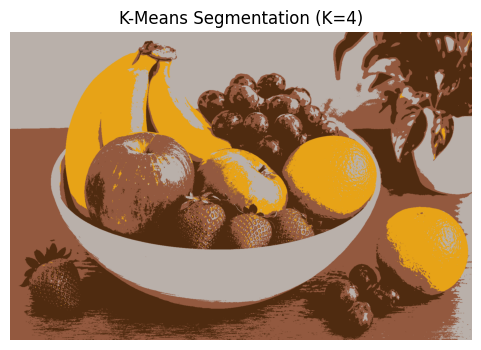

In [9]:
t0 = time.perf_counter()
pixel_values = img_rgb.reshape((-1, 3)).astype(np.float32)
K = 4
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)
labels = kmeans.fit_predict(pixel_values)
centers = np.uint8(kmeans.cluster_centers_)
segmented_kmeans = centers[labels].reshape(img_rgb.shape)
t_kmeans = time.perf_counter() - t0
print("K-Means Clustering")
print("------------------")
print("Number of clusters:", K)
print("Processing Time:", t_kmeans, "seconds")
plt.figure(figsize=(6, 4))
plt.imshow(segmented_kmeans)
plt.title(f"K-Means Segmentation (K={K})")
plt.axis("off")
plt.show()

In [10]:
print("Computational Performance Comparison")
print("-------------------------------------")
print(f"Global Thresholding   : {t_global:.6f} seconds")
print(f"Otsu Thresholding     : {t_otsu:.6f} seconds")
print(f"Adaptive Thresholding : {t_adaptive:.6f} seconds")
print(f"Watershed             : {t_watershed:.6f} seconds")
print(f"K-Means               : {t_kmeans:.6f} seconds")

Computational Performance Comparison
-------------------------------------
Global Thresholding   : 0.004994 seconds
Otsu Thresholding     : 0.001585 seconds
Adaptive Thresholding : 0.039192 seconds
Watershed             : 0.704669 seconds
K-Means               : 14.231818 seconds


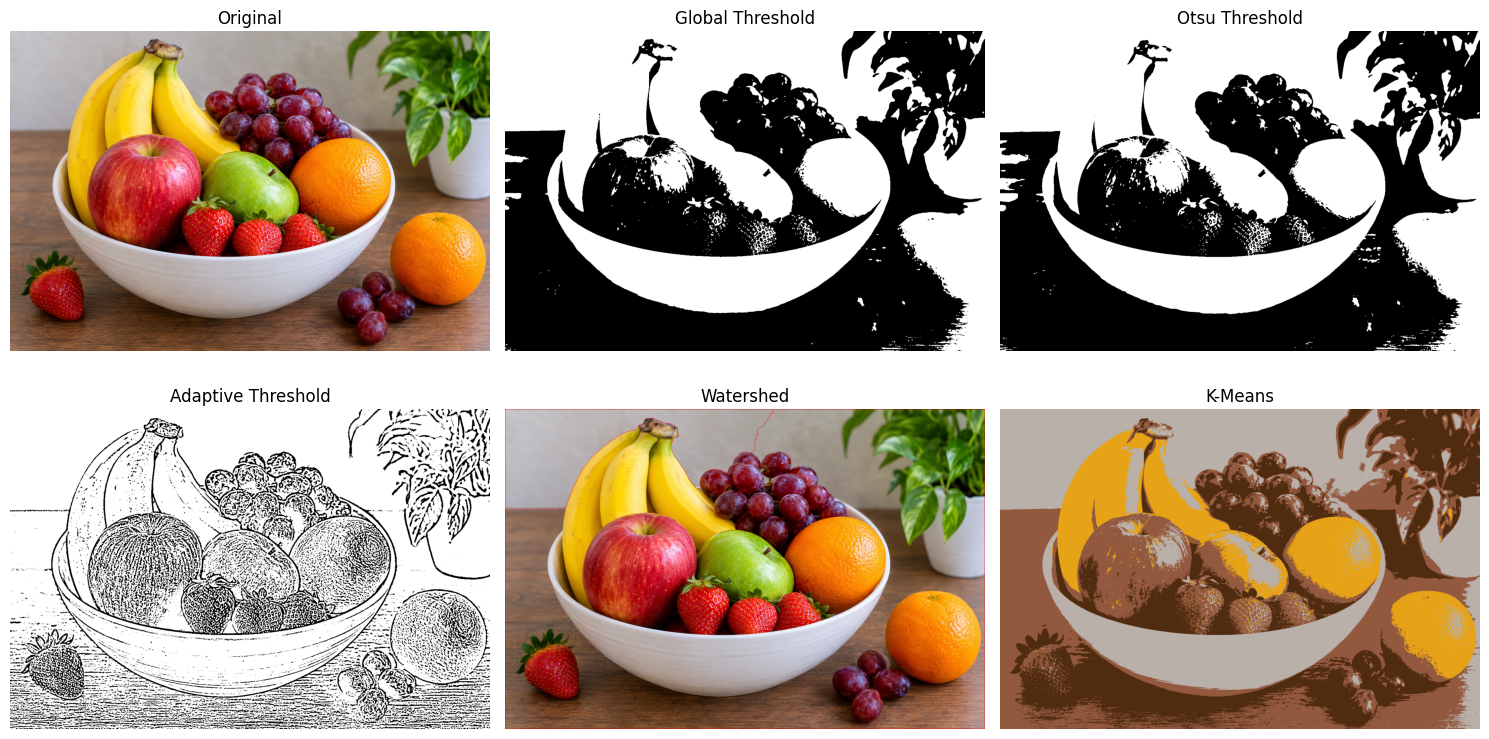

In [11]:
titles = [
    "Original",
    "Global Threshold",
    "Otsu Threshold",
    "Adaptive Threshold",
    "Watershed",
    "K-Means"
]
images = [
    img_rgb,
    global_thresh,
    otsu_thresh,
    adaptive_thresh,
    cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB),
    segmented_kmeans
]
plt.figure(figsize=(15, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    if images[i].ndim == 2:
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
print("OBSERVATIONS")
print("------------")
print("1. Global Thresholding uses a fixed threshold value of 127.")
print("2. Otsu's Thresholding automatically selects a suitable threshold.")
print("3. Adaptive Thresholding calculates threshold values locally.")
print("4. Watershed is useful for separating touching or overlapping objects.")
print("5. K-Means groups pixels according to their color similarity.")
print("6. Thresholding techniques are simple and fast.")
print("7. K-Means generally requires more computational time.")
print("8. Different segmentation methods are suitable for different types of images.")

OBSERVATIONS
------------
1. Global Thresholding uses a fixed threshold value of 127.
2. Otsu's Thresholding automatically selects a suitable threshold.
3. Adaptive Thresholding calculates threshold values locally.
4. Watershed is useful for separating touching or overlapping objects.
5. K-Means groups pixels according to their color similarity.
6. Thresholding techniques are simple and fast.
7. K-Means generally requires more computational time.
8. Different segmentation methods are suitable for different types of images.
